# 0. 导入必要的库

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

import torchvision
show = torchvision.transforms.ToPILImage()

import itertools
import pandas as pd
from contextlib import redirect_stdout
from typing import Optional

# Import utility functions
from my_utils import (
    CIFAR_10_MEAN,
    CIFAR_10_STD,
    CIFAR_10_CLASS,
    get_device,
    get_cifar10_data_augmentation,
    train_model,
    evaluate,
    plot_loss_curves,
    count_parameters,
    create_learning_rate_scheduler
)

# 1. 数据准备

In [2]:
# Set image normalization transforms and download the dataset
os.makedirs('./dataset', exist_ok=True)

# Get light augmentation for LeNet baseline (only flips + crops).
transform_train_light, transform_test = get_cifar10_data_augmentation(style='light')

# Get full augmentation for modern CNN (Task4) — stored here for later use.
transform_train_full, _ = get_cifar10_data_augmentation(style='full')

batch_size = 64

# Load CIFAR-10 with light augmentation for training
full_trainset = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_train_light
)

# Load CIFAR-10 WITHOUT augmentation for validation (clean metrics for early stopping)
full_trainset_clean = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_test
)

# Split into train/val with consistent indices (same split for both datasets)
val_size = int(0.1 * len(full_trainset))
torch.manual_seed(51)
indices = torch.randperm(len(full_trainset)).tolist()
train_indices = indices[val_size:]
val_indices = indices[:val_size]

trainset = torch.utils.data.Subset(full_trainset, train_indices)
valset = torch.utils.data.Subset(full_trainset_clean, val_indices)

print(f"Train set size: {len(trainset)}, Validation set size: {len(valset)}")

# Test set
testset = torchvision.datasets.CIFAR10(
    root='./dataset', train=False, download=True, transform=transform_test
)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2
)
val_loader = torch.utils.data.DataLoader(
    valset, batch_size=batch_size, shuffle=False, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2
)

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train set size: 45000, Validation set size: 5000


In [ ]:
# CIFAR-10-C: Download corrupted test set for robustness evaluation
#
# CIFAR-10-C contains 19 common corruptions (noise, blur, weather, etc.)
# applied to the CIFAR-10 test set at 5 severity levels.
# Evaluating on it reveals how much a model's accuracy drops under
# distribution shift — a more complete picture than clean accuracy alone.
#
# Dataset source: https://github.com/hendrycks/robustness

import os
import tarfile
import urllib.request

cifar10c_dir = './dataset/CIFAR-10-C'
if not os.path.isdir(cifar10c_dir):
    url = 'https://github.com/hendrycks/robustness/raw/master/CIFAR-10-C.tar'
    tar_path = './dataset/CIFAR-10-C.tar'
    print('Downloading CIFAR-10-C (170 MB, may take a while)...')
    urllib.request.urlretrieve(url, tar_path)
    print('Extracting...')
    with tarfile.open(tar_path, 'r') as tar:
        tar.extractall(path='./dataset')
    os.remove(tar_path)
    print('CIFAR-10-C downloaded and extracted to ./dataset/CIFAR-10-C/')
else:
    print('CIFAR-10-C already exists, skipping download.')
print(f'Corruptions available: {len(os.listdir(cifar10c_dir))} files')


CIFAR-10 Dataset Statistics
Full training set:  50000 images
  - Training split: 45000 images
  - Validation split: 5000 images
Test set:           10000 images
Image dimensions:   torch.Size([3, 32, 32])
Number of CIFAR_10_CLASS:  10

Class Distribution:
----------------------------------------
  0: plane      5000 images (10.0%)
  1: car        5000 images (10.0%)
  2: bird       5000 images (10.0%)
  3: cat        5000 images (10.0%)
  4: deer       5000 images (10.0%)
  5: dog        5000 images (10.0%)
  6: frog       5000 images (10.0%)
  7: horse      5000 images (10.0%)
  8: ship       5000 images (10.0%)
  9: truck      5000 images (10.0%)


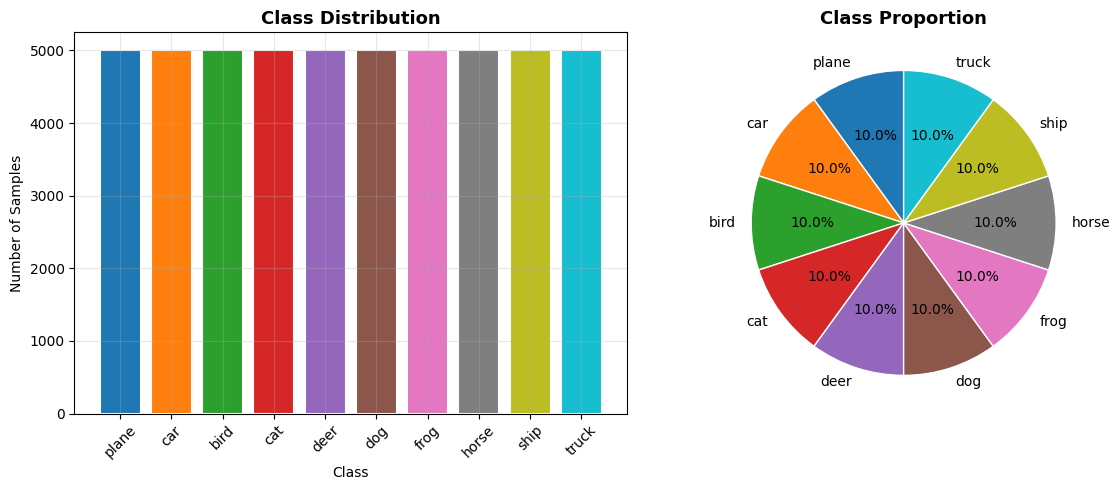

In [3]:
# Data Exploration: Class Distribution and Dataset Statistics
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
FIGURE_DIR = Path('figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
save_path = FIGURE_DIR / 'data_exploration_class_distribution.pdf'

# Collect labels from the full training set
train_labels = [full_trainset[i][1] for i in range(len(full_trainset))]
class_counts = [train_labels.count(i) for i in range(10)]

print("=" * 60)
print("CIFAR-10 Dataset Statistics")
print("=" * 60)
print(f"Full training set:  {len(full_trainset):>5} images")
print(f"  - Training split: {len(trainset):>5} images")
print(f"  - Validation split:{len(valset):>5} images")
print(f"Test set:           {len(testset):>5} images")
print(f"Image dimensions:   {full_trainset[0][0].shape}")
print(f"Number of CIFAR_10_CLASS:  {len(CIFAR_10_CLASS)}")
print()
print("Class Distribution:")
print("-" * 40)
for i, (cls, count) in enumerate(zip(CIFAR_10_CLASS, class_counts)):
    print(f"  {i}: {cls:<8s}  {count:>5} images ({100 * count / len(full_trainset):.1f}%)")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10(np.arange(10))

ax1.bar(CIFAR_10_CLASS, class_counts, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.pie(class_counts, labels=CIFAR_10_CLASS, autopct='%1.1f%%', colors=colors,
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax2.set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


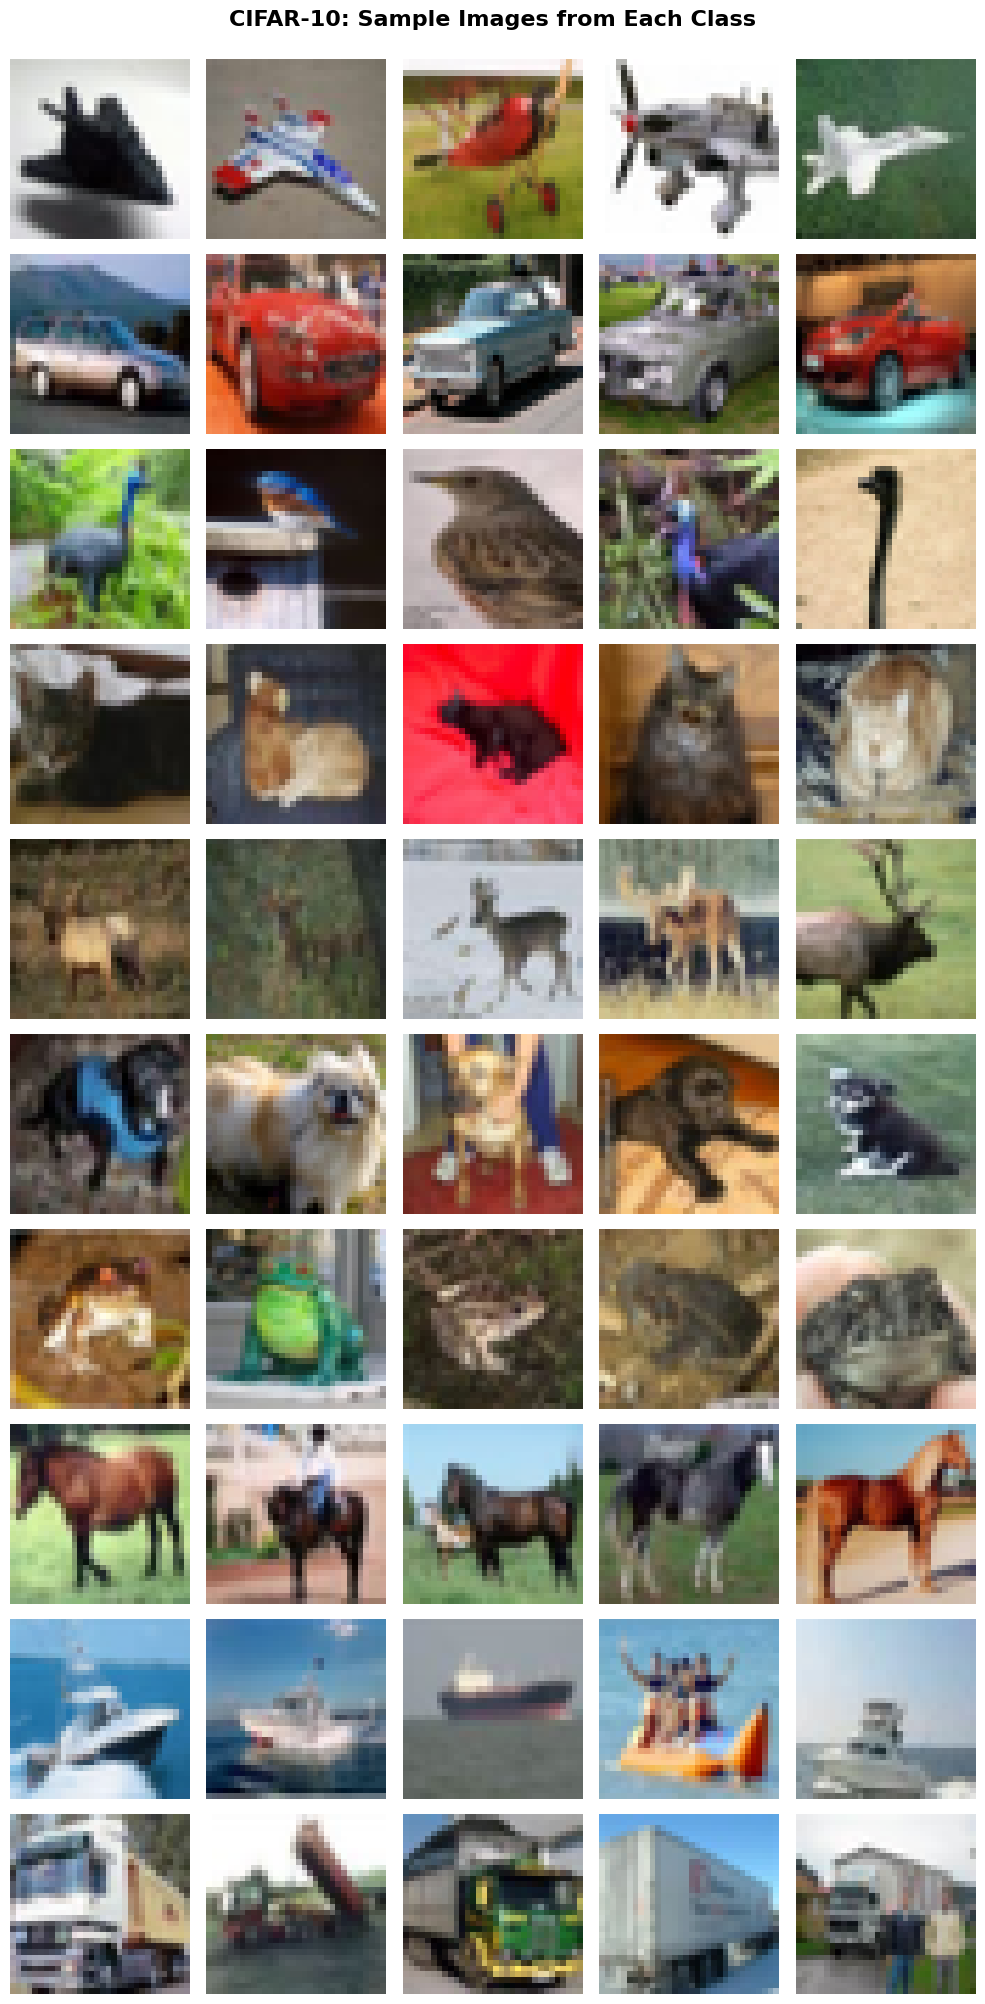

In [4]:
# Data Exploration: Sample Grid from Each Class
save_path = FIGURE_DIR / 'data_exploration_sample_grid.pdf'
samples_per_class = 5

# Load raw training set (without augmentation for clean display)
raw_trainset = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR_10_MEAN, CIFAR_10_STD)
    ])
)

# Collect images per class
class_samples = {i: [] for i in range(10)}
for img, label in raw_trainset:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(img)
    if all(len(v) >= samples_per_class for v in class_samples.values()):
        break

# Plot grid: 10 rows (CIFAR_10_CLASS) x 5 columns (samples)
fig, axes = plt.subplots(10, samples_per_class, figsize=(samples_per_class * 2, 20))
fig.suptitle('CIFAR-10: Sample Images from Each Class', fontsize=16, fontweight='bold', y=1)

mean_t = torch.tensor(CIFAR_10_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_10_STD).view(3, 1, 1)

for i in range(10):
    for j in range(samples_per_class):
        img = class_samples[i][j]
        img_display = img * std_t + mean_t  # Denormalize
        axes[i, j].imshow(img_display.permute(1, 2, 0).clamp(0, 1).numpy())
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(CIFAR_10_CLASS[i], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Per-Channel Pixel Statistics (raw [0, 1] range)
   Red | Mean: 0.4914 | Std: 0.2470 | Min: 0.0000 | Max: 1.0000
 Green | Mean: 0.4822 | Std: 0.2435 | Min: 0.0000 | Max: 1.0000
  Blue | Mean: 0.4465 | Std: 0.2616 | Min: 0.0000 | Max: 1.0000

Overall   | Mean: 0.4734 | Std: 0.2516


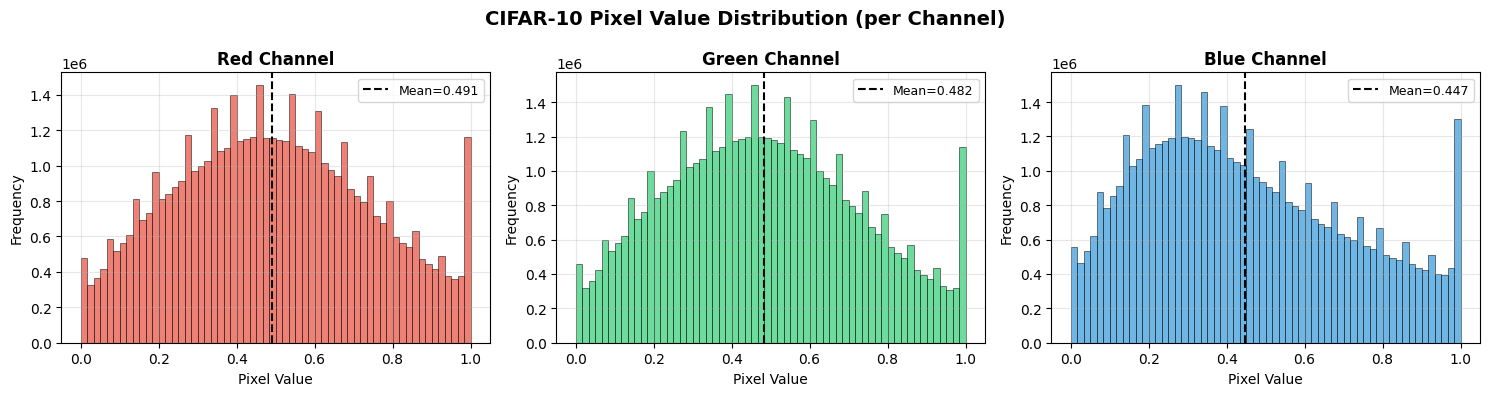

In [5]:
# Data Exploration: Per-Channel Pixel Statistics and Histograms
save_path = FIGURE_DIR / 'data_exploration_pixel_histograms.pdf'
raw_trainset_stats = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False,
    transform=torchvision.transforms.ToTensor()
)

# Stack images
all_pixels = np.stack([np.asarray(raw_trainset_stats[i][0]) for i in range(len(raw_trainset_stats))])

print("=" * 70)
print("Per-Channel Pixel Statistics (raw [0, 1] range)")
print("=" * 70)
channels = ['Red', 'Green', 'Blue']
for i, ch_name in enumerate(channels):
    ch = all_pixels[:, i, :, :]
    print(f"{ch_name:>6} | Mean: {ch.mean():.4f} | Std: {ch.std():.4f} | "
          f"Min: {ch.min():.4f} | Max: {ch.max():.4f}")

print()
print(f"Overall   | Mean: {all_pixels.mean():.4f} | Std: {all_pixels.std():.4f}")

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_hist = ['#e74c3c', '#2ecc71', '#3498db']

for i, (ch_name, color) in enumerate(zip(channels, colors_hist)):
    ch_data = all_pixels[:, i, :, :].flatten()
    axes[i].hist(ch_data, bins=60, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].axvline(ch_data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={ch_data.mean():.3f}')
    axes[i].set_title(f'{ch_name} Channel', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('CIFAR-10 Pixel Value Distribution (per Channel)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


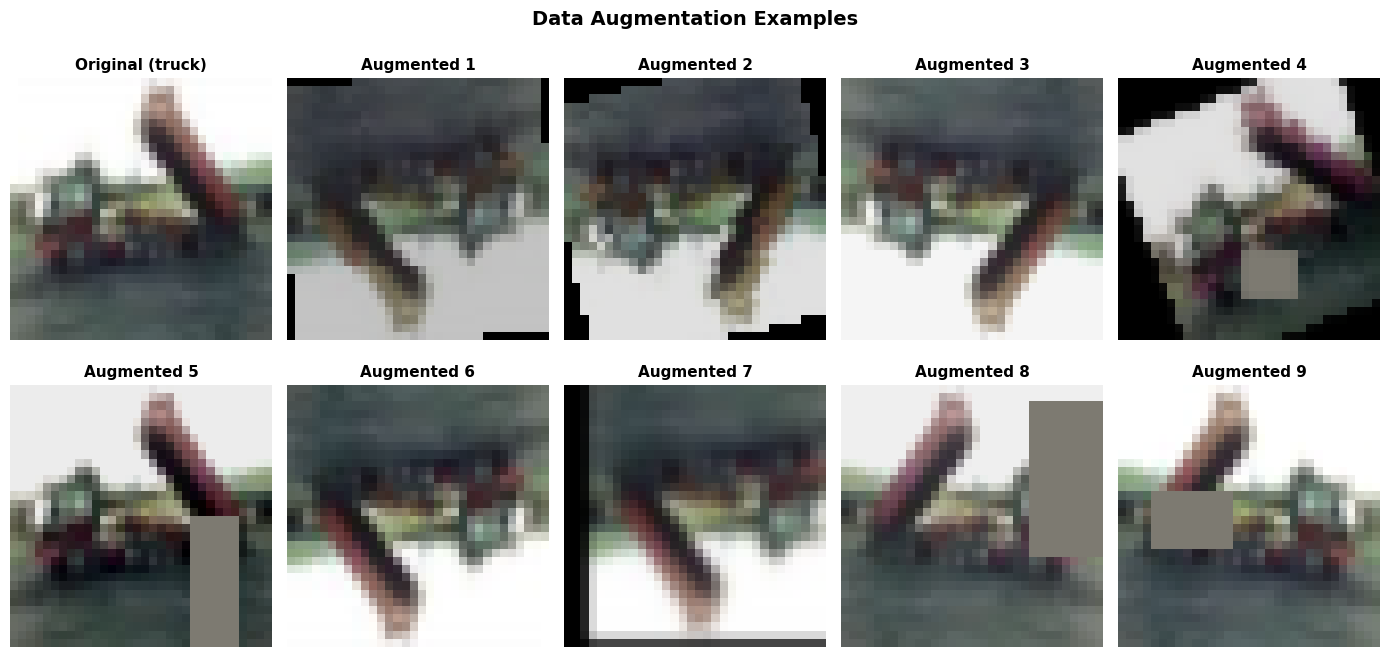

Augmentation visualization saved.
Class: truck


In [6]:
# Data Exploration: Data Augmentation Visualization
# Get a clean PIL image and its label
save_path = FIGURE_DIR / 'data_exploration_augmentation.pdf'
raw_pil_dataset = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False
)
sample_img, sample_label = raw_pil_dataset[2]

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
axes = axes.flatten()

mean_t = torch.tensor(CIFAR_10_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_10_STD).view(3, 1, 1)

# Original image (no augmentation)
axes[0].imshow(np.array(sample_img))
axes[0].set_title(f'Original ({CIFAR_10_CLASS[sample_label]})', fontsize=11, fontweight='bold')
axes[0].axis('off')

# 9 augmented versions using transform_train_full (heavy augmentation for visualization)
for i in range(1, 10):
    aug = transform_train_full(sample_img)
    aug_display = aug * std_t + mean_t  # Denormalize
    axes[i].imshow(aug_display.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[i].set_title(f'Augmented {i}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Augmentation visualization saved.\nClass: {CIFAR_10_CLASS[sample_label]}")

# 2. 定义用于分类的网络结构

这一部分我们定义用于图像分类的网络结构，实现一个早期的卷积神经网络LeNet。它由两个卷积层和三个全连接层组成。pytorch为我们提供了方便的接口定义神经网络，但我们这里不着重介绍具体的语法，只观察数据是怎样在模型中“流动”的：
- 在`__init__`方法中，我们将上述的卷积层和全连接层初始化为`conv1、conv2`和`fc1、fc2、fc3`；
- 卷积层以`conv1`为例，它的初始化为`Conv2d(3, 6, 5)`，即：3输入通道（RGB图像的三个通道）、6输出通道、5*5大小的卷积核的卷积层。
- 全连接层以`fc1`为例，它的初始化为`Linear(16 * 5 * 5, 120)`，即：从400维映射到120维。
- `forward`方法用于规定数据在模型中的计算过程。输入的形状在传播过程中的变化参见`forward`中的注释。最终，我们得到了一个大小为`[batch size, 10]`的张量（矩阵）。

In [ ]:
class LeNet(nn.Module):
    """LeNet-style CNN for CIFAR-10 image classification.
    
    Original architecture adapted for 32×32 RGB images.
    Consists of two convolutional layers and three fully connected layers.
    """
    
    def __init__(self, dropout: Optional[float] = None) -> None:
        # Subclasses of nn.Module must call the parent class constructor
        super(LeNet, self).__init__()

        # Convolutional layer: 3 input channels (RGB), 6 output channels, 5x5 kernel
        self.conv1 = nn.Conv2d(3, 6, 5) 
        # Convolutional layer
        self.conv2 = nn.Conv2d(6, 16, 5) 
        # Fully connected layers: y = Wx + b
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)
        # Optional dropout layer for regularization
        self.dropout = None
        if dropout is not None:
            if isinstance(dropout, float) and 0 < dropout < 1:
                self.dropout = nn.Dropout(dropout)
            else:
                raise ValueError("dropout must be a float between 0 and 1")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the network.
        
        Args:
            x: Input tensor of shape (batch_size, 3, 32, 32).
            
        Returns:
            Output tensor of shape (batch_size, 10).
        """
        # Convolution -> ReLU -> MaxPool (ReLU does not change shape)
        # [batch_size, 3, 32, 32] -- conv1 --> [batch_size, 6, 28, 28] -- maxpool --> [batch_size, 6, 14, 14]
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # [batch_size, 6, 14, 14] -- conv2 --> [batch_size, 16, 10, 10] -- maxpool --> [batch_size, 16, 5, 5]
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        # Flatten the 16 * 5 * 5 feature map into [batch_size, 16 * 5 * 5] for the fully connected layers
        x = x.view(x.size()[0], -1) 
        # [batch_size, 16 * 5 * 5] -- fc1 --> [batch_size, 120]
        x = F.relu(self.fc1(x))
        # [batch_size, 120] -- fc2 --> [batch_size, 84]
        if self.dropout is not None:
            x = self.dropout(x)
        x = F.relu(self.fc2(x))
        # [batch_size, 84] -- fc3 --> [batch_size, 10]
        x = self.fc3(x)        
        return x

lenet_baseline = LeNet(dropout=None)
print(lenet_baseline)

param_counts = count_parameters(lenet_baseline)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Total parameters: 62.006KK
Trainable parameters: 62.006KK, Non-trainable parameters: 0


# 3. 模型训练与测试过程
准备好数据、定义好模型后，我们开始训练过程。为了把一个随机初始化的模型优化成一个“好”的模型，我们还需要定义：
- 损失函数$\mathcal{L}$：损失函数以一般同时以模型的预测$\hat{y}$和真实的标签$y$为输入，输出一个标量。这个标量越小，说明模型在数据上拟合得越好。我们的目的就是要最小化这个损失函数$\mathcal{L}(\hat{y},y).$分类问题常使用交叉熵函数作为损失函数。
- 优化方法：为了最小化损失函数，我们就要使用数学的优化方法找到一组最优的参数（这里的参数即神经网络中卷积层、全连接层等的参数，而非batch size等超参数）。深度学习中一般使用迭代的方式求解，常用的方法有SGD（随机梯度下降）、Adam等。
pytorch库内置了各种优化器，我们无需手动实现梯度下降过程。

下面我们定义用于训练过程的代码。最外层循环控制在整个数据集上训练的次数（即epoch）；内层循环按照以下流程进行：
1. 取出数据（一次取出一个batch）；
2. 将数据送入网络，计算损失函数；
3. 使用损失函数计算梯度，进行反向传播更新参数。

In [8]:
# Set device (GPU if available)
device = get_device()
print(f"Using device: {device}")

# Move model to device
lenet_baseline = lenet_baseline.to(device)

# --- Shared hyperparameters (used across multiple experiments) ---
LR = 0.001
MIN_LR = LR * 0.1
MOMENTUM = 0.9
NUM_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10

# --- Baseline experiment ---
LABEL_SMOOTHING = 0.0  # Will be adjusted in Task3

criterion_baseline = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

weight_decay_baseline = 0.0  # No L2 regularization; will be adjusted in Task2
optimizer_baseline = optim.SGD(
    lenet_baseline.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=weight_decay_baseline
)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={weight_decay_baseline})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create learning rate scheduler config (linear warm-up + cosine annealing with restarts)
scheduler_config_baseline = create_learning_rate_scheduler(
    optimizer_baseline, 
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS, 
    initial_lr=LR,
    min_lr=MIN_LR
)

# Train the network
save_path_baseline = 'checkpoints/lenet_baseline'
train_losses_baseline, val_accuracies_baseline = train_model(
    model=lenet_baseline,
    train_loader=train_loader,
    criterion=criterion_baseline,
    optimizer=optimizer_baseline,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_baseline,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_baseline
)

print(f"Final training loss: {train_losses_baseline[-1]:.4f}")
if val_accuracies_baseline:
    print(f"Final validation accuracy: {val_accuracies_baseline[-1]:.2f}%")

Using GPU: NVIDIA GeForce RTX 4090
Using device: cuda:0
Loss function: CrossEntropyLoss (label_smoothing=0.0)
Optimizer: SGD (lr=0.001, momentum=0.9, weight_decay=0.0)
Epochs: 100 (with early stopping)
Created CosineAnnealingWarmRestarts (T_0=50, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.001
  Min LR: 0.0001, Total epochs: 100
Training on device: cuda:0
Epoch 1/100: Train Loss: 2.2995, Val Accuracy: 16.70%, Learning Rate: 0.000200, Grad Norm: 0.2229
  -> New best model saved with accuracy: 16.70%
Epoch 2/100: Train Loss: 2.2840, Val Accuracy: 19.04%, Learning Rate: 0.000400, Grad Norm: 0.3052
  -> New best model saved with accuracy: 19.04%
Epoch 3/100: Train Loss: 2.1514, Val Accuracy: 28.30%, Learning Rate: 0.000600, Grad Norm: 1.0144
  -> New best model saved with accuracy: 28.30%
Epoch 4/100: Train Loss: 1.9719, Val Accuracy: 31.02%, Learning Rate: 0.000800, Grad Norm: 1.9784
  -> New best model saved with accuracy: 31.02%
Epoch 5/100: Train Loss: 1.8577, Val Accuracy: 35.12%, 

训练过程结束后，我们得到了一个在训练集上拟合较好的模型。下面我们要测试它在测试集上表现如何。预测的代码与训练中的正向传播类似，但是不需要计算损失函数（损失函数在实验中仅用于更新参数，预测时参数固定，也就不需要它了）。

预测的流程如下：
1. 取出数据；
2. 正向传播，得到模型的输出结果；
3. 从输出结果中得到模型预测；
4. 和真实标签进行比对，计算性能指标。

注意：模型的输出结果在第2部分中已经说明，为一个`[batch size, 10]`大小的张量（矩阵），每一行是一条数据属于10个类别的概率的相对大小（这一输出也被称为`logits`）。为了得到模型的预测，我们需要对这一输出在每行上取最大值，取得最大值的**位置**就是模型的预测。

In [ ]:
# Evaluate on test set
print("\nEvaluating LeNet baseline on test set...")
test_result_baseline = evaluate(model=lenet_baseline, test_loader=test_loader, device=device)
test_accuracy_baseline = test_result_baseline['accuracy']

# Results comparison
print("\n=== Baseline Results ===")
if val_accuracies_baseline:
    print(f"  - Best validation accuracy:   {max(val_accuracies_baseline):.2f}%")
    print(f"  - Final validation accuracy:  {val_accuracies_baseline[-1]:.2f}%")
else:
    print("  - Validation accuracy: N/A")
print(f"  - Test accuracy:              {test_accuracy_baseline:.2f}%")


# Task1：绘制损失函数曲线
损失函数能够量化模型在数据集上的拟合程度，帮助我们了解模型训练的进程。请在`3.模型训练与测试过程`中补充代码，记录训练过程中损失`loss`的变化，使用合适的Python数据类型将其保存，并使用`matplotlib`库将其可视化。可参照以下的代码进行绘图。你可以直接用损失函数可视化的代码覆盖下面的代码块。

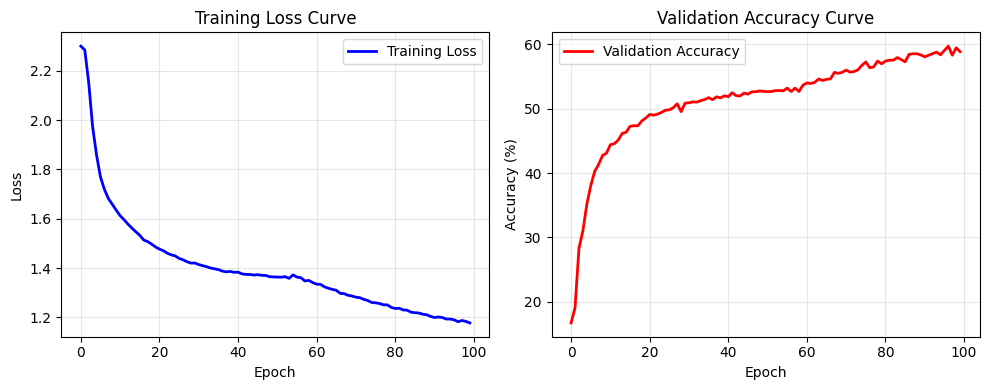

Loss curve saved to figures/lenet_baseline_loss_curve.pdf
Final training loss: 1.1776
Final validation accuracy: 58.86%


In [10]:
# Plot loss curves using utility function
plot_loss_curves(train_losses_baseline, val_accuracies_baseline, FIGURE_DIR / 'lenet_baseline_loss_curve.pdf')

In [11]:
# Clean up GPU memory
del lenet_baseline, optimizer_baseline, criterion_baseline, scheduler_config_baseline
del train_losses_baseline, val_accuracies_baseline
torch.cuda.empty_cache()

请在报告中附上训练过程中损失函数的变化。训练集上的损失越小，说明模型的效果就越好吗？

# Task2: 加入正则化

- $L_2$正则化：请查阅Pytorch[有关SGD优化器的文档](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd)或其它网络资料，修改`3. 模型训练与测试过程`中的代码，尝试为模型的损失函数加入一项$L_2$损失，并在报告中说明你所做的修改。
- Dropout正则化：请查阅Pytorch[有关Dropout层的文档](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#dropout)或其它网络资料，修改`2. 定义用于分类的网络结构`中的代码，在**第一个线性层和第二个线性层之间**加入一个Dropout层，并在报告中说明你所做的修改。
- 在报告中简述两种正则化方法的基本原理。

In [12]:
lenet_dropout = LeNet(dropout=0.2)
print(lenet_dropout)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


Loss function: CrossEntropyLoss (label_smoothing=0.0)
Optimizer: SGD (lr=0.001, momentum=0.9, weight_decay=0.0001)
Epochs: 100 (with early stopping)
Created CosineAnnealingWarmRestarts (T_0=50, T_mult=2)
  Warm-up: 5 epoch(s), Initial LR: 0.001
  Min LR: 0.0001, Total epochs: 100
Training on device: cuda:0
Epoch 1/100: Train Loss: 2.3039, Val Accuracy: 10.16%, Learning Rate: 0.000200, Grad Norm: 0.2081
  -> New best model saved with accuracy: 10.16%
Epoch 2/100: Train Loss: 2.2973, Val Accuracy: 14.38%, Learning Rate: 0.000400, Grad Norm: 0.2301
  -> New best model saved with accuracy: 14.38%
Epoch 3/100: Train Loss: 2.2306, Val Accuracy: 25.30%, Learning Rate: 0.000600, Grad Norm: 0.5542
  -> New best model saved with accuracy: 25.30%
Epoch 4/100: Train Loss: 2.0387, Val Accuracy: 29.10%, Learning Rate: 0.000800, Grad Norm: 1.5737
  -> New best model saved with accuracy: 29.10%
Epoch 5/100: Train Loss: 1.9394, Val Accuracy: 33.12%, Learning Rate: 0.001000, Grad Norm: 2.0195
  -> New b

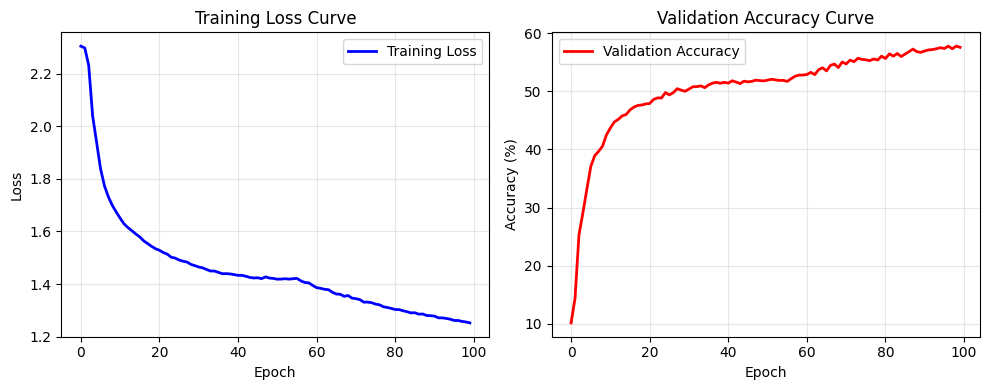

Loss curve saved to figures/lenet_dropout_loss_curve.pdf
Final training loss: 1.2526
Final validation accuracy: 57.58%


In [13]:
# Task2: Train model with Dropout + L2 regularization
# Move model to device
lenet_dropout = lenet_dropout.to(device)

# Dropout experiment: L2 regularization via weight_decay
weight_decay_dropout = 1e-4
optimizer_dropout = optim.SGD(
    lenet_dropout.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=weight_decay_dropout
)
criterion_dropout = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={weight_decay_dropout})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create learning rate scheduler config (separate instance for this optimizer)
scheduler_config_dropout = create_learning_rate_scheduler(
    optimizer_dropout, 
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS,
    initial_lr=LR,
    min_lr=MIN_LR
)

# Train Dropout network with L2 regularization
save_path_dropout = 'checkpoints/lenet_dropout'
train_losses_dropout, val_accuracies_dropout = train_model(
    model=lenet_dropout,
    train_loader=train_loader,
    criterion=criterion_dropout,
    optimizer=optimizer_dropout,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_dropout,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_dropout
)

# Plot loss curves
plot_loss_curves(train_losses_dropout, val_accuracies_dropout, FIGURE_DIR / 'lenet_dropout_loss_curve.pdf')

In [ ]:
# Evaluate on test set
print("\nEvaluating LeNet with Dropout on test set...")
test_result_dropout = evaluate(model=lenet_dropout, test_loader=test_loader, device=device)
test_accuracy_dropout = test_result_dropout['accuracy']

# Results comparison
print("\n=== Task2 Results: Dropout + L2 Regularization ===")
if val_accuracies_dropout:
    print(f"  - Best validation accuracy:   {max(val_accuracies_dropout):.2f}%")
    print(f"  - Final validation accuracy:  {val_accuracies_dropout[-1]:.2f}%")
else:
    print("  - Validation accuracy: N/A")
print(f"  - Test accuracy:              {test_accuracy_dropout:.2f}%")

In [15]:
# Clean up GPU memory
del lenet_dropout, optimizer_dropout, criterion_dropout, scheduler_config_dropout
del train_losses_dropout, val_accuracies_dropout
torch.cuda.empty_cache()

# Task3: 调整参数
在`3. 模型训练与测试过程`部分中，我们定义了一些超参数（如`num_epoch`、优化器的`lr`）。调节这些参数，观察损失函数以及模型在测试集上的性能变化，在报告中简要说明这些指标的变化，尝试分析这些超参数对整个模型的影响。

In [ ]:
# Task3: Hyperparameter Tuning Experiments (3x3x2x2 grid, 36 experiments)
# Parallel execution with 9 concurrent worker processes.

import concurrent.futures
import multiprocessing as mp

from task3_worker import train_experiment

# Hyperparameter grid
LR_GRID = [0.001, 0.005, 0.01]
WD_GRID = [0, 1e-3, 1e-2]
LS_GRID = [0, 0.05]
BS_GRID = [16, 64]
NUM_EXPERIMENTS = len(LR_GRID) * len(WD_GRID) * len(LS_GRID) * len(BS_GRID)

print("=" * 70)
print("Task3: Hyperparameter Tuning Experiments (Parallel)")
print(f"  lr           = {LR_GRID}")
print(f"  weight_decay = {WD_GRID}")
print(f"  label_smooth = {LS_GRID}")
print(f"  batch_size   = {BS_GRID}")
print(f"  Total: {NUM_EXPERIMENTS} experiments x {NUM_EPOCHS} epochs each")
print(f"  Workers: 9 concurrent on GPU")
print("=" * 70)

# Create output directories
LOG_DIR = Path('logs/task3')
LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = Path('checkpoints/task3')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Prepare argument list for all 36 experiments.
# train_indices / val_indices are the lists from the data-prep cell above.
experiment_args = []
for exp_idx, (lr, wd, ls, bs) in enumerate(
    itertools.product(LR_GRID, WD_GRID, LS_GRID, BS_GRID), 1
):
    experiment_args.append((
        exp_idx, lr, wd, ls, bs,
        train_indices, val_indices,
        NUM_EPOCHS, str(CKPT_DIR), str(LOG_DIR)
    ))

results = []

# Use spawn context for safe CUDA multiprocessing
ctx = mp.get_context('spawn')

print(f"\nStarting parallel execution with 9 workers...")
print(f"Multiprocessing context: {ctx.get_start_method()}\n")

with concurrent.futures.ProcessPoolExecutor(max_workers=9, mp_context=ctx) as executor:
    # Submit all experiments to the pool
    future_map = {
        executor.submit(train_experiment, *args): args
        for args in experiment_args
    }

    # Collect results as they complete
    for future in concurrent.futures.as_completed(future_map):
        args = future_map[future]
        exp_idx = args[0]
        try:
            result = future.result()
            results.append(result)
            print(f"[{result['experiment_id']:02d}/{NUM_EXPERIMENTS}] "
                  f"lr={result['learning_rate']}, wd={result['weight_decay']}, "
                  f"ls={result['label_smoothing']}, bs={result['batch_size']} | "
                  f"best_val_acc={result['best_val_accuracy']:.2f}%, "
                  f"epochs={result['epochs_trained']}")
        except Exception as e:
            print(f"[{exp_idx:02d}/{NUM_EXPERIMENTS}] FAILED: {e}")

# Sort by experiment_id for consistent ordering
results.sort(key=lambda r: r['experiment_id'])

In [17]:
# --- Results summary ---
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("Hyperparameter Tuning Results (sorted by best_val_accuracy):")
print("=" * 70)
print(results_df.sort_values('best_val_accuracy', ascending=False).to_string(index=False))

# Save to CSV
results_df.to_csv('task3_hyperparameter_results.csv', index=False)
print(f"\nResults saved to 'task3_hyperparameter_results.csv'")
print(f"Full logs saved to {LOG_DIR}/")

# --- Visualization ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, param, values, title in [
    (axes[0, 0], 'learning_rate', LR_GRID, 'Learning Rate'),
    (axes[0, 1], 'weight_decay', WD_GRID, 'Weight Decay'),
    (axes[1, 0], 'label_smoothing', LS_GRID, 'Label Smoothing'),
    (axes[1, 1], 'batch_size', BS_GRID, 'Batch Size'),
]:
    for val in values:
        data = results_df[results_df[param] == val]
        if len(data) > 0:
            ax.bar(
                [str(e) for e in data['experiment_id']],
                data['best_val_accuracy'],
                alpha=0.7, label=f'{param.split("_")[-1]}={val}'
            )
    ax.set_xlabel('Experiment ID')
    ax.set_ylabel('Best Val Accuracy (%)')
    ax.set_title(f'Effect of {title}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/task3_hyperparameter_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

# --- Best combination ---
best = results_df.loc[results_df['best_val_accuracy'].idxmax()]
print("\n" + "=" * 70)
print("Best Hyperparameter Combination:")
print("=" * 70)
for col in results_df.columns:
    print(f"  {col}: {best[col]}")
print("=" * 70)

# Task4: 实现自己的网络
查阅资料（参考：[动手学深度学习](https://zh.d2l.ai/chapter_convolutional-modern/index.html)以及[`torchvision`的模型源码](https://github.com/pytorch/vision/tree/main/torchvision/models)），修改`2. 定义用于分类的网络结构`中的代码，实现一种现代卷积神经网络。与最基础的LeNet相比，你实现的神经网络在性能、训练时间上有何差异？

In [ ]:
class BasicBlock(nn.Module):
    """Basic residual block for ResNet-18."""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = F.relu(out)
        return out


class MyCNN(nn.Module):
    """Manually implemented ResNet-18 for CIFAR-10."""

    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.in_channels = 64
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * BasicBlock.expansion,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion)
            )
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * BasicBlock.expansion
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Instantiate MyCNN
mycnn = MyCNN(dropout_rate=0.3)
print(mycnn)

param_counts = count_parameters(mycnn)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)


In [ ]:
# Task4: MyCNN (ResNet-18) — Instantiate, configure, and train
# Create DataLoader with full augmentation for modern CNN
full_trainset_full_aug = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_train_full
)
trainset_full_aug = torch.utils.data.Subset(full_trainset_full_aug, train_indices)
train_loader_full = torch.utils.data.DataLoader(
    trainset_full_aug, batch_size=64, shuffle=True, num_workers=2
)

# Move model to device
mycnn = mycnn.to(device)

# Configure optimizer and loss
LR_MYCNN = 0.001
MIN_LR_MYCNN = LR_MYCNN * 0.1

criterion_mycnn = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer_mycnn = optim.Adam(mycnn.parameters(), lr=LR_MYCNN, weight_decay=1e-4)

print(f"Loss function: CrossEntropyLoss (label_smoothing=0.05)")
print(f"Optimizer: Adam (lr={LR_MYCNN}, weight_decay=1e-4)")
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")

# Create LR scheduler
scheduler_config_mycnn = create_learning_rate_scheduler(
    optimizer_mycnn,
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS,
    initial_lr=LR_MYCNN,
    min_lr=MIN_LR_MYCNN
)

# Train
save_path_mycnn = 'checkpoints/mycnn'
train_losses_mycnn, val_accuracies_mycnn = train_model(
    model=mycnn,
    train_loader=train_loader_full,
    criterion=criterion_mycnn,
    optimizer=optimizer_mycnn,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_mycnn,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_mycnn
)

print(f"Final training loss: {train_losses_mycnn[-1]:.4f}")
if val_accuracies_mycnn:
    print(f"Final validation accuracy: {val_accuracies_mycnn[-1]:.2f}%")

# Plot loss curves
plot_loss_curves(train_losses_mycnn, val_accuracies_mycnn, FIGURE_DIR / 'mycnn_loss_curve.pdf')

/root/Snape/Introduction-to-AI-Project-01/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


MyCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


ValueError: Cannot specify ',' with 's'.

In [ ]:
# Evaluate on test set
print("\nEvaluating MyCNN on test set...")
test_result_mycnn = evaluate(model=mycnn, test_loader=test_loader, device=device)
test_accuracy_mycnn = test_result_mycnn['accuracy']

# Comparison with baseline model
print("\n" + "="*70)
print("Task4 Results: MyCNN (ResNet-18) vs Baseline LeNet")
print("="*70)
print("MyCNN (ResNet-18):")
if val_accuracies_mycnn:
    print(f"  - Best validation accuracy:   {max(val_accuracies_mycnn):.2f}%")
    print(f"  - Final validation accuracy:  {val_accuracies_mycnn[-1]:.2f}%")
else:
    print("  - Validation accuracy: N/A")
print(f"  - Test accuracy:              {test_accuracy_mycnn:.2f}%")
print(f"  - Epochs trained:             {len(train_losses_mycnn)}")
print(f"  - Total parameters:           {param_counts['total']:,}")

print("\nAnalysis:")
print("1. Parameter count: MyCNN (~11M) is far larger than LeNet (~62K)")
print("2. Training time: MyCNN requires more time per epoch due to its depth")
print("3. Regularization: MyCNN includes BatchNorm and Dropout to prevent overfitting")
print("4. Full augmentation (ColorJitter, Rotation, RandomErasing) boosts generalization")
print("5. Expected: MyCNN achieves significantly higher accuracy than LeNet")
print("="*70)

In [ ]:
# Clean up GPU memory
del mycnn, optimizer_mycnn, criterion_mycnn, scheduler_config_mycnn
del train_losses_mycnn, val_accuracies_mycnn, param_counts
torch.cuda.empty_cache()